In [1]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import galsim
import os
from astropy.table import Table

from scipy.interpolate import interp1d

colors = {'u' : 'purple', 'g':'blue', 'r': 'green', 'i': 'orange', 'z' : 'magenta', 'y' : 'red'}

from utils import apply_filter, apply_DCR, mean_and_std

# def apply_filter(wvl, data, band = 'g', rm_leakage = True):
#     '''
#     wvl - a list of the wavelengths in angstroms
#     data - a N x M list of SEDs, N = number of SEDs, M = len of wvl
#     returns data with the band filter applied to each SED
#     '''
    
#     filter_file = f'filter_files/total_{band}.dat'
#     filter_band = np.loadtxt(filter_file).T #filter_band[0] -> wavelengths, filter_band[1] -> filter pass fraction

#     # remove filter leakage: set lower bound of filter to 0.001 throughput
#     if rm_leakage:
#         leakage_mask = filter_band[1] < 0.001
#         filter_band[1][leakage_mask] = np.zeros(np.sum(leakage_mask))
    
#     func = interp1d(filter_band[0], filter_band[1])
#     SED_filter = func(wvl)
    
#     return data * SED_filter
    

#Pat and Josh's paper atmospheric conditions 
pressure=69.328
temperature=293.15
H2O_pressure=1.067


# def apply_DCR(wave, filtered_data, zenith, pressure, temperature, H2O_pressure):
#     '''
#     wave - list of wavelength points
#     filtered_data - dictionary, keys: bands, items: list of flux throughputs for each SED as viewed in that band 

#     Takes in SED data with the filter throughputs already applied, returns refraction_angles (mapped from wave) and filtered_refracted_data (the flux density over refraction angles)

#     '''
#     dwvl = 0.1 #wavelength step
#     wave_temp = np.arange(290, 1160, dwvl)

#     #Get dR/dwavelength function
#     refraction = galsim.dcr.get_refraction(
#         wave_temp,
#         zenith_angle=zenith * galsim.degrees,
#         pressure=pressure,  # kPa
#         temperature=temperature,  # K
#         H2O_pressure=H2O_pressure,  # kPa
#         ) * 180 * 3600 / np.pi #convert from radians to arcsec

#     dR_dwvl = (refraction[1:] - refraction[0:-1])/dwvl
#     wavelengths_midpoints = wave_temp[0:-1] + dwvl/2
    
#     dRdwvl_func = interp1d(wavelengths_midpoints, dR_dwvl)

#     #Get the refraction angle of each passed in wavelength 
#     refraction_angles = galsim.dcr.get_refraction(
#             wave,
#             zenith_angle=zenith * galsim.degrees,
#             pressure=pressure,  # kPa
#             temperature=temperature,  # K
#             H2O_pressure=H2O_pressure,  # kPa
#             ) * 180 * 3600 / np.pi #convert from radians to arcsec
    
    
#     filtered_refracted_data = {} #dictionary which will store dN/dR 
    
#     for band, data in filtered_data.items():
#         filtered_refracted_data[band] = np.abs(data * wave / dRdwvl_func(wave))

#     return refraction_angles, filtered_refracted_data


import warnings

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.collections import LineCollection


def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

def find_degeneracies(color_mags, redshifts, color1_name = 'g-r', color2_name = 'r-i'):
    color1 = np.array(color_mags[color1_name])
    color2 = np.array(color_mags[color2_name])
    z  = np.array(redshifts)

    def ccw(A, B, C):
        return (C[1]-A[1])*(B[0]-A[0]) > (B[1]-A[1])*(C[0]-A[0])

    def intersect(A, B, C, D):
        return ccw(A,C,D) != ccw(B,C,D) and ccw(A,B,C) != ccw(A,B,D)

    intersections = []

    N = len(color1)

    for i in range(N-1):
        A = (color1[i], color2[i])
        B = (color1[i+1], color2[i+1])
        
        for j in range(i+2, N-1):
            # Skip adjacent segments to avoid trivial "intersections"
            if j == i or j == i+1:
                continue
                
            C = (color1[j], color2[j])
            D = (color1[j+1], color2[j+1])
            
            if intersect(A, B, C, D):
                intersections.append((i, j))

    print(f"Geometric intersection segment pairs for {color1_name} vs {color2_name}:")
    print(intersections)

    degeneracies = []
    for (i, j) in intersections:
        print(f"\nIntersection between:")
        print(f"  Segment [{i} → {i+1}] at z ≈ {z[i]:.4f}–{z[i+1]:.4f}")
        print(f"  and segment [{j} → {j+1}] at z ≈ {z[j]:.4f}–{z[j+1]:.4f}")
        print('color1:', (color1[i], color2[i]), 'to', (color1[i+1], color2[i+1]))

        degeneracies.append([(z[i + 1] - z[i])/2 + z[i], (z[j + 1] - z[j])/2 + z[j]])
    return degeneracies, intersections

(2, 1762)


Text(0.5, 0, 'Wavelength (nm)')

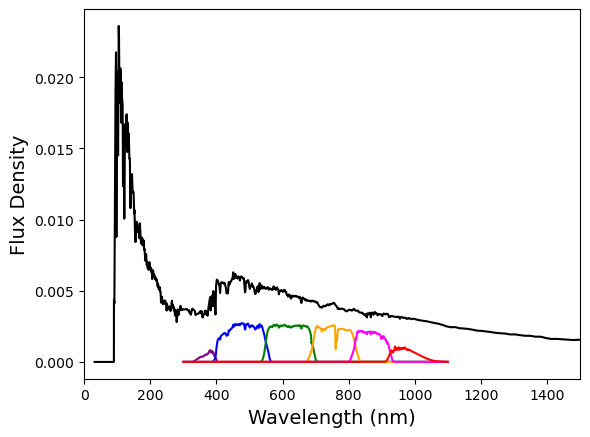

In [2]:
gal_file = 'COSMOS_SED/S0_A_0.sed'
gal_file = 'COSMOS_SED/Ell1_A_0.sed'
gal_file = 'COSMOS_SED/SB0_A_0.sed'
# gal_file = 'COSMOS_SED/Sc_A_0.sed'
# gal_file = 'COSMOS_SED/SB11_A_0.sed'
# gal_file = 'COSMOS_SED/Sdm_A_0.sed'

data = np.loadtxt(gal_file).T

print(data.shape)

wvl = data[0] / 10
flux = data[1] 

#mask out zero values:
# mask = flux > 0
# flux[~mask] = np.nan

filtered_flux = {}
wave = np.linspace(300, 1100, 1000)
for band in 'ugrizy':
    filtered_flux[band] = apply_filter(wave, interp1d(wvl, flux)(wave), band = band) 
    plt.plot(wave, filtered_flux[band], label = band, color = colors[band])



plt.plot(wvl, flux , 'k-')
# plt.xscale('log')
plt.xlim(0, 1500)
# plt.yscale('log')
plt.ylabel('Flux Density', fontsize = 14)
plt.xlabel('Wavelength (nm)', fontsize = 14)


{'u': np.float64(373.55667308105643), 'g': np.float64(487.14748855582246), 'r': np.float64(622.726434354283), 'i': np.float64(754.5557726224658), 'z': np.float64(866.7028001660376), 'y': np.float64(973.759446962109)}


(0.0, 1500.0)

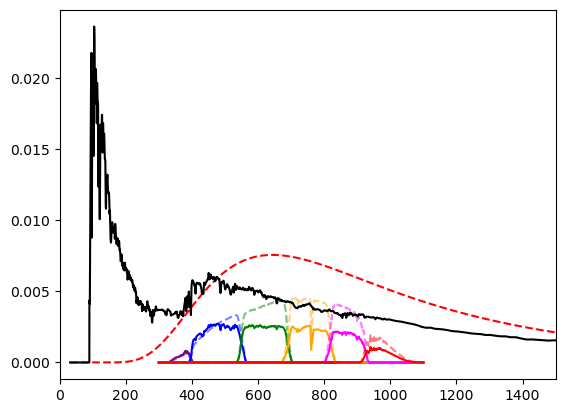

In [3]:
#create the reference blackbody spectrum

from astropy.modeling.models import BlackBody
from astropy.constants import c
import astropy.units as u


def BB(wave, temp, scale):
    temp = temp * u.K
    wave = wave * u.AA
    scale = scale * u.erg / (u.cm**2 * u.s * u.AA * u.sr)

    bb = BlackBody(temperature = temp, scale = scale)
    return bb(wave).value 


reference_temperature = 4500 #4500 #K

bb_flux = BB(wvl * 10, reference_temperature, 1e-8)
# bb_flux = np.zeros(len(wvl))
# bb_flux[(wvl > 300) & (wvl < 500)] = bb_flux[(wvl > 300) & (wvl < 500)] + wvl[(wvl > 300) & (wvl < 500)] * (-1) + 500

filtered_flux = {}
wave = np.linspace(300, 1100, 1000)


for band in 'ugrizy':
    filtered_flux[band] = apply_filter(wave, [interp1d(wvl, flux)(wave), interp1d(wvl, bb_flux)(wave)], band = band)
    plt.plot(wave, filtered_flux[band][0], label = band, color = colors[band])
    plt.plot(wave, filtered_flux[band][1], ls = '--', label = band, alpha = 0.5, color = colors[band])


reference_wavelengths, _ = mean_and_std(wave, {band: filtered_flux[band][1] for band in 'ugrizy'}, multi = False)
print(reference_wavelengths)

plt.plot(wvl, bb_flux, 'r--', label = 'BB: 4500K')
plt.plot(wvl, flux, 'k-', label = 'Galaxy SED')

# plt.xscale('log')
# plt.yscale('log')
plt.xlim(0, 1500)


(200.0, 1500.0)

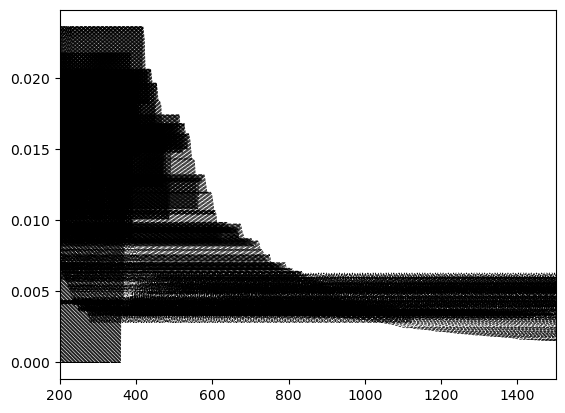

In [4]:
# Redshift the spectrum and calculate DCR effects
from astropy import constants as const

redshifts = np.linspace(1.5, 3, 200)
redshifts = np.linspace(0, 3, 200)


zenith = 45
zeniths = [15, 30, 45, 60]


DCR1 = {}
for band in 'ugrizy':
    DCR1[band] = {}
    for zenith in zeniths:
        DCR1[band][zenith] = []

photometry = {}
for band in 'ugrizy':
    photometry[band] = []

mean_wavelength = {}
for band in 'ugrizy':
    mean_wavelength[band] = []



for z in redshifts:
    shifted_wvl = wvl * (1 + z)

    plt.plot(shifted_wvl, flux, 'k--', linewidth = 0.5)

    filtered_flux = {}
    wave = np.linspace(300, 1100, 1000)

    for band in 'ugrizy':
        filtered_flux[band] = apply_filter(wave, [interp1d(shifted_wvl, flux)(wave), interp1d(wvl, bb_flux)(wave)], band = band)
        # plt.plot(wave, filtered_flux[band][0], label = band, color = colors[band], linewidth = 0.5)

        #photometry:
        photometry[band].append(np.trapezoid(filtered_flux[band][0] * wave, wave))

        #mean wavelength:
        if np.sum(filtered_flux[band][0]) == 0:
            mean_wavelength[band].append(np.nan)
        else:
            mean_wavelength[band].append(np.average(wave, weights = filtered_flux[band][0]))


    for zenith in zeniths:
        refraction_angles, filtered_refracted_data = apply_DCR(wave, filtered_flux, zenith, pressure, temperature, H2O_pressure)

        means, stdevs = mean_and_std(refraction_angles, filtered_refracted_data, multi = True)
        for band in 'ugrizy':
            DCR1[band][zenith].append(means[band])
    

plt.xlim(200, 1500)
    


In [5]:
# Calculate and save colors

for band in 'ugrizy':
    photometry[band] = np.array(photometry[band])
    mean_wavelength[band] = np.array(mean_wavelength[band])
        
    for zenith in zeniths:
        DCR1[band][zenith] = np.array(DCR1[band][zenith])

# print(DCR1['u'][45][:,1])

color_mags = {}

color_mags['u-g'] = -2.5 * np.log10(photometry['u'] / photometry['g'])
color_mags['g-r'] = -2.5 * np.log10(photometry['g'] / photometry['r'])
color_mags['r-i'] = -2.5 * np.log10(photometry['r'] / photometry['i'])
color_mags['i-z'] = -2.5 * np.log10(photometry['i'] / photometry['z'])
color_mags['z-y'] = -2.5 * np.log10(photometry['z'] / photometry['y'])


print(photometry['g'][0:5])
print(color_mags['g-r'][0:5])

# [0.47187468 0.47430595 0.47669681 0.4790361  0.48134896]
# [-0.43377229 -0.43197683 -0.43047482 -0.42889132 -0.42738802]

[171.17809677 171.15184806 170.82994085 170.4506499  169.98449523]
[0.27616319 0.29063847 0.30674502 0.32180157 0.3351656 ]


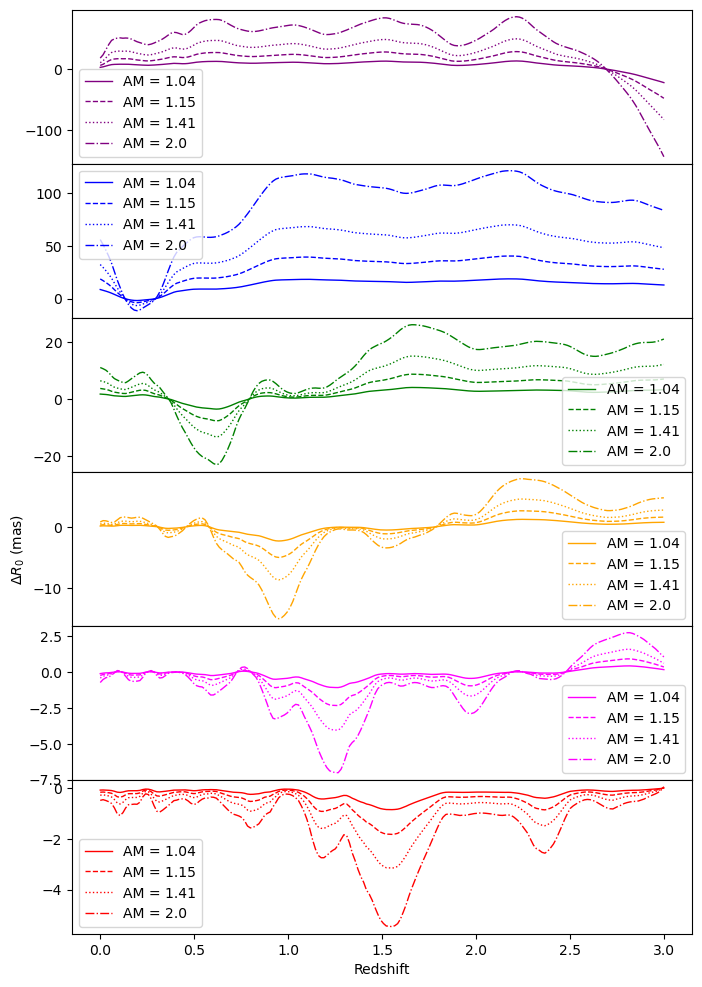

In [6]:
# Plot DCR vs redshift
linestyles = {15 : 'solid', 30 : 'dashed', 45 : 'dotted', 60 : 'dashdot'}

fig, ax = plt.subplots(6, 1, figsize = (8,12), sharex = True)
zenith = 45
fig.subplots_adjust(hspace=0)

for i, band in enumerate('ugrizy'):
    mask = np.isnan(DCR1[band][zenith][:,0]) == False
    for zenith in zeniths:
        # ax[i].plot(redshifts[mask], DCR1[band][mask][:,1], ls = '--', color = colors[band], label = band)
        ax[i].plot(redshifts[mask], (DCR1[band][zenith][mask][:,0] - DCR1[band][zenith][mask][:,1]) * 1000, color = colors[band], linewidth = 1.0, ls = linestyles[zenith], label = f'AM = {np.round(1/np.cos(zenith*np.pi/180),2)}')
        ax[i].legend()
        
# plt.xlim(0, 1.2)
ax[3].set_ylabel(r'$\Delta R_{0}$ (mas)')
plt.xlabel('Redshift')
# plt.tight_layout()
plt.show()

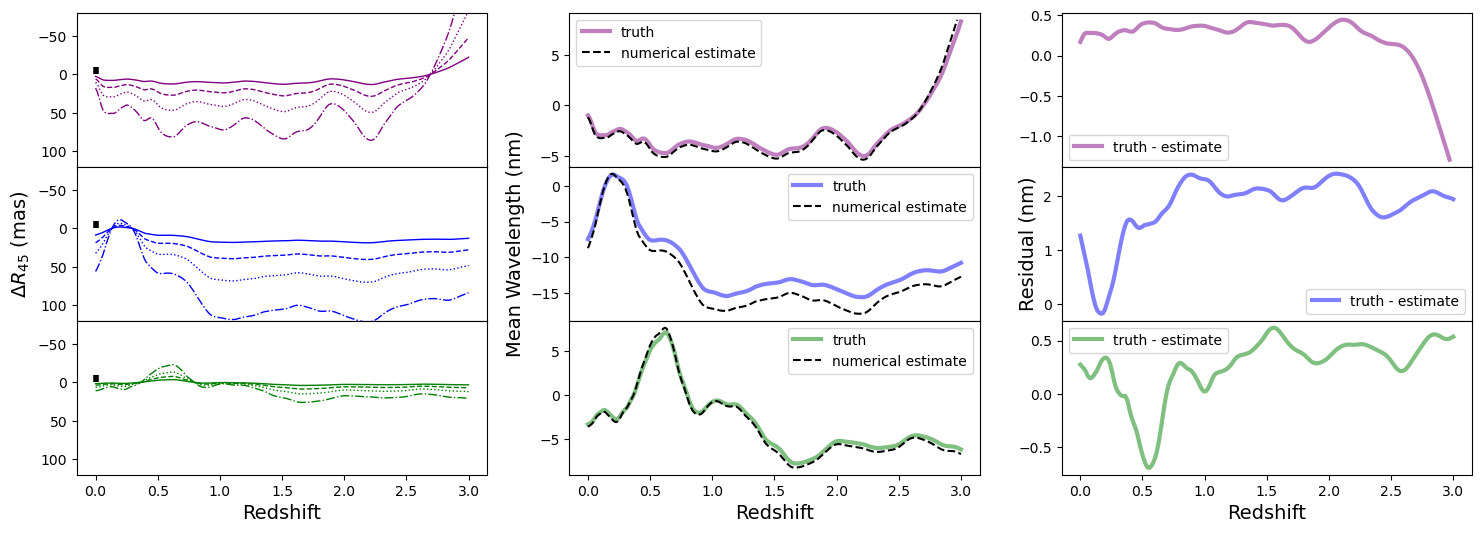

In [7]:
from wavelength_estimate import generate_templates, estimate_mean_wave, analytic_mean_wave

templates = generate_templates(reference_temperature = 4500, sigma = 100, gaussian = False)

linestyles = {15 : 'solid', 30 : 'dashed', 45 : 'dotted', 60 : 'dashdot'}

fig, ax = plt.subplots(3, 3, figsize = (18,6), sharex = True)
zenith = 45
fig.subplots_adjust(hspace=0)

for i, band in enumerate('ugr'): #izy'):
    mask = np.isnan(DCR1[band][zenith][:,0]) == False

    R0 = DCR1[band][45][mask][:,0] - DCR1[band][45][mask][:,1]

    # ax[i].plot(redshifts[mask], photometry[band][mask], color = colors[band], label = band)
    ax[i,1].plot(redshifts[mask], mean_wavelength[band][mask] - reference_wavelengths[band], color = colors[band], linewidth = 3,alpha = 0.5, label = 'truth')
    ax[i,1].plot(redshifts[mask], estimate_mean_wave(R0, band, *templates) - reference_wavelengths[band], color = 'k', ls = '--', linewidth = 1.5, label = f'numerical estimate')
    # ax[i,1].plot(redshifts[mask], analytic_mean_wave(R0, band, *templates), color = 'r', ls = '--', linewidth = 1.5, label = f'analytic estimate')

    # ax[i,1].invert_yaxis()
    ax[i,1].legend()


    # ax[i].plot(redshifts[mask], photometry[band][mask], color = colors[band], label = band)
    ax[i,2].plot(redshifts[mask], mean_wavelength[band][mask] - estimate_mean_wave(R0, band, *templates), color = colors[band], linewidth = 3,alpha = 0.5, label = 'truth - estimate')
    # ax[i,2].plot(redshifts[mask], mean_wavelength[band][mask] - analytic_mean_wave(R0, band, *templates),ls = '--', color = colors[band], linewidth = 3,alpha = 0.5, label = 'truth - analytic')
    # ax[i,2].plot(redshifts[mask], estimate_mean_wave(R0, band, *templates), color = 'k', ls = '--', linewidth = 1.5, label = f'estimate')

    # ax[i,2].invert_yaxis()
    ax[i,2].legend()

    for zenith in zeniths:
        # ax[i].plot(redshifts[mask], DCR1[band][mask][:,1], ls = '--', color = colors[band], label = band)
        ax[i,0].plot(redshifts[mask], (DCR1[band][zenith][mask][:,0] - DCR1[band][zenith][mask][:,1])*1000, color = colors[band], linewidth = 1.0, ls = linestyles[zenith], label = f'AM = {np.round(1/np.cos(zenith*np.pi/180),2)}')
    
    ax[i,0].errorbar(min(redshifts[mask]), -5, yerr = 5, elinewidth = 4, fmt = '', color = 'k')
    # ax[i,0].legend()
    ax[i,0].set_ylim(-80, 120)

    ax[i,0].invert_yaxis()
        
# plt.xlim(0, 1.2)
ax[1, 0].set_ylabel(r'$\Delta R_{45}$ (mas)', fontsize = 14)
ax[1, 1].set_ylabel('Mean Wavelength (nm)', fontsize = 14)
ax[1, 2].set_ylabel('Residual (nm)', fontsize = 14)
ax[2, 0].set_xlabel('Redshift', fontsize = 14)
ax[2, 1].set_xlabel('Redshift', fontsize = 14)
ax[2, 2].set_xlabel('Redshift', fontsize = 14)
# plt.tight_layout()
plt.show()

/var/folders/ns/g2qjv9ld66v981bvx8j2b4zh0000gn/T/ipykernel_19449/2793345151.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2,0].legend()


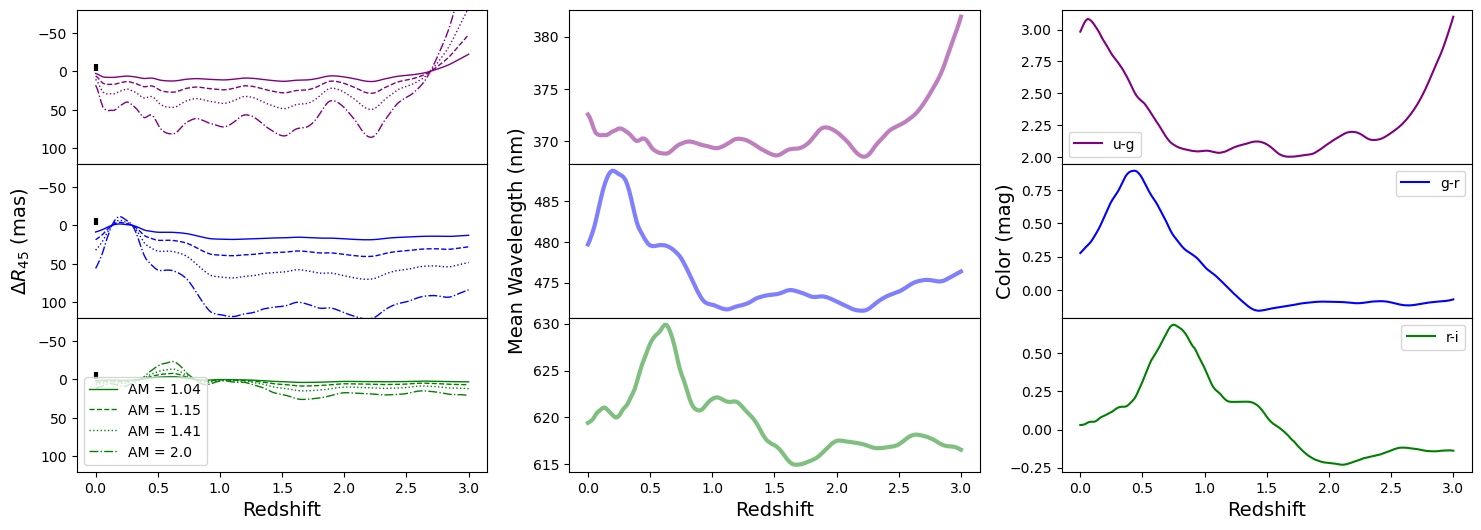

In [8]:
from wavelength_estimate import generate_templates, estimate_mean_wave, analytic_mean_wave

templates = generate_templates(reference_temperature = 4500, sigma = 100, gaussian = False)

linestyles = {15 : 'solid', 30 : 'dashed', 45 : 'dotted', 60 : 'dashdot'}



filter_to_plot = ['u', 'g', 'r']
phot_colors = ['u-g', 'g-r', 'r-i']
fig, ax = plt.subplots(len(filter_to_plot), 3, figsize = (18,6), sharex = True)
zenith = 45
fig.subplots_adjust(hspace=0)

for i, band in enumerate(filter_to_plot):
    mask = np.isnan(DCR1[band][zenith][:,0]) == False

    R0 = DCR1[band][45][mask][:,0] - DCR1[band][45][mask][:,1]

    # ax[i].plot(redshifts[mask], photometry[band][mask], color = colors[band], label = band)
    ax[i,1].plot(redshifts[mask], mean_wavelength[band][mask], color = colors[band], linewidth = 3,alpha = 0.5, label = 'truth')
    # ax[i,1].plot(redshifts[mask], estimate_mean_wave(R0, band, *templates), color = 'k', ls = '--', linewidth = 1.5, label = f'gaussian estimate')
    # ax[i,1].plot(redshifts[mask], analytic_mean_wave(R0, band, *templates), color = 'r', ls = '--', linewidth = 1.5, label = f'analytic estimate')

    # ax[i,1].invert_yaxis()
    # ax[i,1].legend()


    ax[i,2].plot(redshifts[mask], color_mags[phot_colors[i]][mask], color = colors[band], label = phot_colors[i])
    # ax[i,2].plot(redshifts[mask], mean_wavelength[band][mask] - estimate_mean_wave(R0, band, *templates), color = colors[band], linewidth = 3,alpha = 0.5, label = 'truth - estimate')
    # ax[i,2].plot(redshifts[mask], mean_wavelength[band][mask] - analytic_mean_wave(R0, band, *templates),ls = '--', color = colors[band], linewidth = 3,alpha = 0.5, label = 'truth - analytic')
    # ax[i,2].plot(redshifts[mask], estimate_mean_wave(R0, band, *templates), color = 'k', ls = '--', linewidth = 1.5, label = f'estimate')

    # ax[i,2].invert_yaxis()
    ax[i,2].legend()

    for zenith in zeniths:
        # ax[i].plot(redshifts[mask], DCR1[band][mask][:,1], ls = '--', color = colors[band], label = band)
        ax[i,0].plot(redshifts[mask], (DCR1[band][zenith][mask][:,0] - DCR1[band][zenith][mask][:,1])*1000, color = colors[band], linewidth = 1.0, ls = linestyles[zenith], label = f'AM = {np.round(1/np.cos(zenith*np.pi/180),2)}')
    
    ax[i,0].errorbar(min(redshifts[mask]), -5, elinewidth = 3,yerr = 5, fmt = '', color = 'k')
    ax[2,0].legend()
    ax[i,0].set_ylim(-80, 120)

    ax[i,0].invert_yaxis()
        
# plt.xlim(0, 1.2)
ax[int(len(filter_to_plot)/2), 0].set_ylabel(r'$\Delta R_{45}$ (mas)', fontsize = 14)
ax[int(len(filter_to_plot)/2), 1].set_ylabel('Mean Wavelength (nm)', fontsize = 14)
ax[int(len(filter_to_plot)/2), 2].set_ylabel('Color (mag)', fontsize = 14)
ax[len(filter_to_plot)-1, 0].set_xlabel('Redshift', fontsize = 14)
ax[len(filter_to_plot)-1, 1].set_xlabel('Redshift', fontsize = 14)
ax[len(filter_to_plot)-1, 2].set_xlabel('Redshift', fontsize = 14)
# plt.tight_layout()
plt.show()

In [9]:
# color-color diagrams

from IPython.display import display, HTML

display(HTML("""
<script src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.7/MathJax.js?config=TeX-AMS_HTML"></script>
"""))

color1 = 'g-r'
color2 = 'r-i'



degenerate_redshifts, intersections = find_degeneracies(color_mags, redshifts, color1_name = color1, color2_name = color2)
# print(degenerate_redshifts)
# print(intersections)
intersections = np.array(intersections)
# print(intersections[0])

import plotly.express as px
import plotly.graph_objects as go



fig = px.scatter(x=color_mags[color1], y=color_mags[color2], color=redshifts, color_continuous_scale='turbo')

if len(intersections) > 0:
    fig.add_scatter(x=color_mags[color1][intersections[0]], y=color_mags[color2][intersections[0]], mode='markers',
        marker=dict(
            size=20,
            color='red',
            symbol='star'
        ),
        name = 'Degeneracy Points')


fig.update_layout(
    coloraxis_colorbar=dict(title='Redshift'),
    xaxis_title=color1,
    yaxis_title=color2,
    width=800,
    height=500,
    font = dict(size = 16)
)
# fig.update_layout(
#     legend=dict(
#         x=1,    # move legend right
#         y=1,       # top
#         xanchor="left",
#         bgcolor="rgba(255,255,255,0.8)"  # optional: white background
#     )
# )

fig.update_coloraxes(
    colorbar=dict(
        x=1,   # shift colorbar left (negative = outside plot)
        y=0.4
    )
)

fig.show()


mask =  (np.isnan(DCR1['g'][45][:,0]) == False) & (np.isnan(DCR1['u'][45][:,0]) == False)

fig = px.scatter(x=(DCR1['g'][45][mask][:,0] - DCR1['g'][45][mask][:,1])*1000, y=(DCR1['u'][45][mask][:,0] - DCR1['u'][45][mask][:,1])*1000, color=redshifts, color_continuous_scale='turbo')

# fig.update_yaxes(title_font=dict(size=20))
# fig.update_xaxes(title_font=dict(size=20))


if len(intersections) > 0:
    fig.add_scatter(x=(DCR1['g'][45][mask][intersections[0],0] - DCR1['g'][45][mask][intersections[0],1])*1000, y=(DCR1['u'][45][mask][intersections[0],0] - DCR1['u'][45][mask][intersections[0],1])*1000, mode='markers',
        marker=dict(
            size=20,
            color='red',
            symbol='star'
        ), name = 'Degeneracy Points')
fig.update_coloraxes(
    colorbar=dict(
        x=1,   # shift colorbar left (negative = outside plot)
        y=0.4,
    )
)
fig.update_xaxes(autorange="reversed")
fig.update_yaxes(autorange="reversed")
fig.update_layout(
    coloraxis_colorbar=dict(title='Redshift'),
    xaxis_title= 'R_45 g (mas)',#r"$\Delta R_{45} $ g (mas)",
    yaxis_title='R_45 r (mas)',#r"$\Delta R_{45}$ r (mas)",
    width = 800,
    height = 500,
    font = dict(size = 16)
)
fig.show()

# mask =  (np.isnan(DCR1['u'][45][:,0]) == False) & (np.isnan(DCR1['g'][45][:,0]) == False)

# fig = px.scatter(x=mean_wavelength['g'][mask], y=mean_wavelength['r'][mask], color=redshifts, color_continuous_scale='turbo')
# fig.update_layout(
#     coloraxis_colorbar=dict(title='Redshift'),
#     xaxis_title='mean wavelength g (nm)',
#     yaxis_title='mean wavelength r (nm)',
#     width = 700,
#     height = 500
# )

# if len(intersections) > 0:
#     fig.add_scatter(x=mean_wavelength['g'][intersections[0]], y=mean_wavelength['r'][intersections[0]], mode='markers',
#         marker=dict(
#             size=20,
#             color='red',
#             symbol='star'
#         ))
# fig.update_coloraxes(
#     colorbar=dict(
#         x=1,   # shift colorbar left (negative = outside plot)
#         y=0.4
#     )
# )

# fig.show()


Geometric intersection segment pairs for g-r vs r-i:
[(117, 168), (118, 183), (123, 152), (164, 188)]

Intersection between:
  Segment [117 → 118] at z ≈ 1.7638–1.7789
  and segment [168 → 169] at z ≈ 2.5327–2.5477
color1: (np.float64(-0.10355327974123446), np.float64(-0.1193603917978462)) to (np.float64(-0.10131688250619408), np.float64(-0.13188022973227717))

Intersection between:
  Segment [118 → 119] at z ≈ 1.7789–1.7940
  and segment [183 → 184] at z ≈ 2.7588–2.7739
color1: (np.float64(-0.10131688250619408), np.float64(-0.13188022973227717)) to (np.float64(-0.09942024601713749), np.float64(-0.14409872368673524))

Intersection between:
  Segment [123 → 124] at z ≈ 1.8543–1.8693
  and segment [152 → 153] at z ≈ 2.2915–2.3065
color1: (np.float64(-0.09338237876694297), np.float64(-0.181481800066054)) to (np.float64(-0.09193201322698331), np.float64(-0.1898000949245312))

Intersection between:
  Segment [164 → 165] at z ≈ 2.4724–2.4874
  and segment [188 → 189] at z ≈ 2.8342–2.8492
col

In [10]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Setup ---
templates = generate_templates(reference_temperature=4500, sigma=100)

linestyles = {
    15: 'solid',
    30: 'dash',
    45: 'dot',
    60: 'dashdot'
}

filter_to_plot = ['u', 'g', 'r']
phot_colors = ['u-g', 'g-r', 'r-i']

nrows = len(filter_to_plot)
ncols = 3

fig = make_subplots(
    rows=nrows,
    cols=ncols,
    shared_xaxes=True,
    horizontal_spacing=0.06,
    vertical_spacing=0.03,
)

# --- Main loops ---
for i, band in enumerate(filter_to_plot):
    
    mask = ~np.isnan(DCR1[band][45][:,0])
    R0 = DCR1[band][45][mask][:,0] - DCR1[band][45][mask][:,1]

    # -------------------------------------------------------
    # Column 2: mean wavelength vs redshift
    # -------------------------------------------------------
    fig.add_trace(
        go.Scatter(
            x=redshifts[mask],
            y=mean_wavelength[band][mask],
            mode='lines',
            line=dict(color=colors[band], width=3),
            name=f"{band} truth",
            legendgroup=f"{band}_truth",
            showlegend=(i == 0)   # only show once
        ),
        row=i+1, col=2
    )
    
    fig.add_trace(
        go.Scatter(
            x=redshifts[mask],
            y=estimate_mean_wave(R0, band, *templates),
            mode='lines',
            line=dict(color='black', width=1.5, dash='dash'),
            name=f"{band} Gaussian estimate",
            legendgroup=f"{band}_estimate",
            showlegend=(i == 0)
        ),
        row=i+1, col=2
    )

    # -------------------------------------------------------
    # Column 3: colors (u-g, g-r, r-i)
    # -------------------------------------------------------
    fig.add_trace(
        go.Scatter(
            x=redshifts[mask],
            y=color_mags[phot_colors[i]][mask],
            mode='lines',
            line=dict(color=colors[band], width=2),
            name=f"{phot_colors[i]}",
            legendgroup=f"{phot_colors[i]}",
            showlegend=(i == 0)
        ),
        row=i+1, col=3
    )

    # -------------------------------------------------------
    # Column 1: ΔR for multiple zenith angles
    # -------------------------------------------------------
    for zen in zeniths:
        fig.add_trace(
            go.Scatter(
                x=redshifts[mask],
                y=(DCR1[band][zen][mask][:,0] - DCR1[band][zen][mask][:,1]) * 1000,
                mode='lines',
                line=dict(color=colors[band], width=1.0, dash=linestyles[zen]),
                name=f"{band}, AM={np.round(1/np.cos(zen*np.pi/180),2)}",
                legendgroup=f"{band}_{zen}",
                showlegend=(i == 0)
            ),
            row=i+1, col=1
        )

    # Invert y-axis for ΔR column
    fig.update_yaxes(autorange="reversed", row=i+1, col=1)

    # Same y-limits
    fig.update_yaxes(range=[120, -80], row=i+1, col=1)

# -------------------------------------------------------
# Global axis labels (equivalent to Matplotlib version)
# -------------------------------------------------------

# Central row y-labels
for col, label in zip([1,2,3], [
    r"ΔR₄₅ (mas)",
    "Mean Wavelength (nm)",
    "Color (mag)"
]):
    fig.update_yaxes(title_text=label, row=nrows//2 + 1, col=col)

# Bottom row x-labels
for col in [1,2,3]:
    fig.update_xaxes(title_text="Redshift", row=nrows, col=col)

# -------------------------------------------------------
# Figure layout
# -------------------------------------------------------
fig.update_layout(
    width=1500,
    height=900,
    title="DCR, Mean Wavelength, and Colors vs Redshift",
    legend=dict(
        x=1.05,
        y=1.0,
        borderwidth=1,
        bgcolor="rgba(255,255,255,0.7)"
    )
)

fig.show()


479.6867705407531
479.6867705407531
[[38.69226276 38.65991233]
 [38.68952313 38.65991233]
 [38.68644333 38.65991233]
 [38.68312819 38.65991233]
 [38.67932394 38.65991233]
 [38.67478072 38.65991233]
 [38.67014188 38.65991233]
 [38.66610844 38.65991233]
 [38.66219015 38.65991233]
 [38.65911974 38.65991233]
 [38.65664499 38.65991233]
 [38.65478997 38.65991233]
 [38.65366282 38.65991233]
 [38.65330276 38.65991233]
 [38.65378695 38.65991233]
 [38.65472414 38.65991233]
 [38.65572282 38.65991233]
 [38.65662477 38.65991233]
 [38.65758958 38.65991233]
 [38.65895695 38.65991233]
 [38.6608454  38.65991233]
 [38.66356322 38.65991233]
 [38.66692269 38.65991233]
 [38.67091547 38.65991233]
 [38.675165   38.65991233]
 [38.67914831 38.65991233]
 [38.68271392 38.65991233]
 [38.68529775 38.65991233]
 [38.68680684 38.65991233]
 [38.6883239  38.65991233]
 [38.68985256 38.65991233]
 [38.69113736 38.65991233]
 [38.69241979 38.65991233]
 [38.69329268 38.65991233]
 [38.69371396 38.65991233]
 [38.69384706 38.65

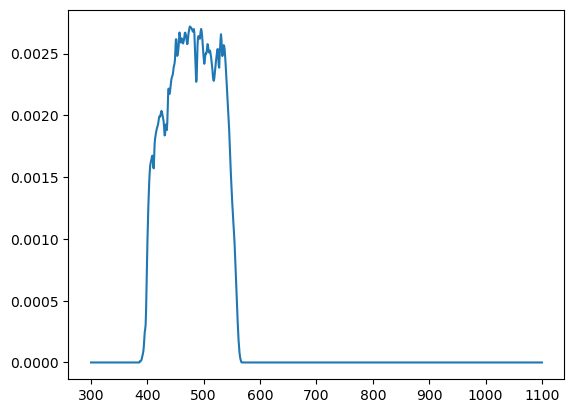

In [11]:
band = 'g'
zenith = 45

mask = np.isnan(DCR1[band][zenith][:,0]) == False
dcr = DCR1[band][zenith][mask][:,0] - DCR1[band][zenith][mask][:,1]

mean_wave = mean_wavelength[band][mask]


flux_ = apply_filter(wave, interp1d(wvl, flux)(wave), band = band)

plt.plot(wave, flux_)

exp = np.sum(flux_ * wave) / np.sum(flux_)

mean_ = np.average(wave, weights = flux_)

print(exp)
print(mean_)


print(DCR1['g'][45])


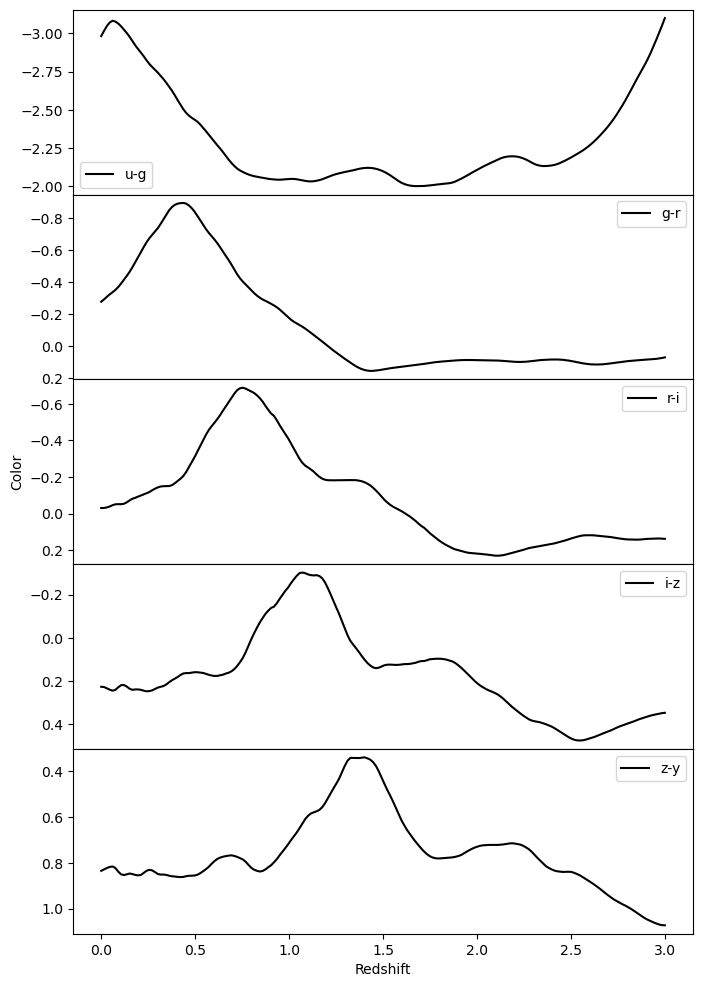

In [12]:
#color plots

fig, ax = plt.subplots(5, 1, figsize = (8,12), sharex = True)
zenith = 45
fig.subplots_adjust(hspace=0)

i = 0
for band, color in color_mags.items():

    mask = np.isnan(DCR1[band[0]][zenith][:,0]) == False

    ax[i].plot(redshifts[mask], -color[mask], color ='k', label = band)
    ax[i].legend()
    ax[i].invert_yaxis()
    # ax[i].plot(redshifts[mask], mean_wavelength[band][mask], color = colors[band], label = band)

    # for zenith in zeniths:
    #     # ax[i].plot(redshifts[mask], DCR1[band][mask][:,1], ls = '--', color = colors[band], label = band)
    #     ax[i].plot(redshifts[mask], DCR1[band][zenith][mask][:,0] - DCR1[band][zenith][mask][:,1], color = colors[band], linewidth = 1.0, ls = linestyles[zenith], label = f'AM = {np.round(1/np.cos(zenith*np.pi/180),2)}')
    #     ax[i].legend()
        
    i += 1


# plt.xlim(0, 1.2)
ax[2].set_ylabel('Color')
plt.xlabel('Redshift')
# plt.tight_layout()
plt.show()


In [13]:


def dNdwave(x, b, c):
    numerator = (
        b**4 * (-1.1692e49 - 1.11504e43*x**4 + 2.72226e39*x**6 - 9.90352e27*x**12 + 4.5036e15*x**18)
        + b**2 * x**4 * (
            -1.77412e59 + 1.8216e56*x**2 - 8.25711e52*x**4 + 2.17534e49*x**6
            + (-3.69146e45 + 2.47588e27*c)*x**8
            + (4.22731e41 - 3.02231e23*c - 7.3787e19*c**2)*x**10
            + (-3.32834e37 + 1.84467e19*c)*x**12
            + (1.80076e33 + 2.2518e15*c)*x**14
            + (-6.56524e28 - 1.67772e7*c**2)*x**16
            + 1.5386e24*x**18
            + (-2.09077e19 + 16.*c)*x**20
            + 1.25124e14*x**22
        )
        + c * x**10 * (
            -1.22911e46 + 8.10894e42*x**2 - 2.2309e39*x**4 + 3.34424e35*x**6
            - 3.00298e31*x**8 + 1.66859e27*x**10 - 5.63795e22*x**12
            + 1.06242e18*x**14 - 8.5586e12*x**16
            + c**3 * x**6 * (-5.15396e10 - 1.19209e-7*x**8)
            + c**2 * (2.41785e24 - 2.36118e21*x**2 + 1.15292e18*x**4
                      - 7.03687e13*x**6 + 8.58993e9*x**8 + 524288.*x**10 - 32.*x**12)
            + c * (-7.9066e42 + 5.61006e39*x**2 - 1.64067e36*x**4 + 2.5862e32*x**6
                   - 2.41957e28*x**8 + 1.39175e24*x**10 - 4.84789e19*x**12
                   + 9.39301e14*x**14 - 7.76691e9*x**16)
        )
        + b * x**6 * (
            -2.609e56 + 2.43941e53*x**2 - 9.90428e49*x**4 + 2.29017e46*x**6
            - 3.32705e42*x**8 + 3.16357e38*x**10 - 1.99157e34*x**12
            + 8.20618e29*x**14 - 2.12438e25*x**16 + 3.13208e20*x**18
            - 2.0052e15*x**20
            + c**3 * x**2 * (9.90352e27 + 1.44115e17*x**6 - 3.51844e13*x**8
                             - 1.07374e9*x**10 - 3.*x**14 + 2.28882e-5*x**16)
            + c * (-1.67832e53 + 1.56923e50*x**2 - 6.40956e46*x**4 + 1.49716e43*x**6
                   - 2.20095e39*x**8 + 2.11566e35*x**10 - 1.34134e31*x**12
                   + 5.53224e26*x**14 - 1.42225e22*x**16 + 2.06301e17*x**18
                   - 1.28566e12*x**20)
            + c**2 * (-4.15384e34 + 8.11296e31*x**2 + 4.8357e24*x**6 - 1.18059e21*x**8
                      + 1.34218e8*x**14 + 4096.*x**16 - 2.38419e-7*x**20)
        )
        + b**3 * x**4 * (
            1.78406e44 - 4.35561e40*x**2 - 1.06338e37*x**4 - 3.16913e29*x**8
            - 7.20576e16*x**14 + 2.19902e12*x**16
            + c * (-4.35561e40 + 1.15292e18*x**12 - 3.8147e-6*x**22)
        )
    )

    denominator = (
        (1.67056e8*x - 31239.6*x**3 + x**5)
        * (
            b**2 * (1.56694e28 - 8.73618e24*x**2 + 1.94304e21*x**4
                    - 2.19422e17*x**6 + 1.31935e13*x**8 - 3.98448e8*x**10
                    + 4728.01*x**12)
            + x**4 * (
                3.38872e22 - 1.26738e19*x**2 + 1.5907e15*x**4 - 7.58655e10*x**6
                + 1.21425e6*x**8
                + c**2 * (1.40228e16 - 6.6412e12*x**2 + 1.02315e9*x**4
                          - 56082.7*x**6 + x**8)
                + c * (4.35979e19 - 1.84768e16*x**2 + 2.55973e12*x**4
                       - 1.30647e8*x**6 + 2203.86*x**8)
            )
            + b * x**2 * (
                4.60866e25 - 2.14655e22*x**2 + 3.74504e18*x**4 - 3.01696e14*x**6
                + 1.11194e10*x**8 - 151539.*x**10
                + c * (2.96466e22 - 1.52847e19*x**2 + 2.89357e15*x**4
                       - 2.48567e11*x**6 + 9.651e6*x**8 - 137.521*x**10)
            )
        )**2
    )

    return numerator / denominator


print(dNdwave(500, 4500, 1e-8))

2.5560839321382152e-09


u (flat): var = 264.3877, ddR = 8.5e-05
0.0112
---
g (flat): var = 1853.555, ddR = 2.7e-05
0.0254
---
r (flat): var = 1711.4112, ddR = 9e-06
0.0079
---
i (flat): var = 1498.1665, ddR = 4e-06
0.0031
---
z (flat): var = 966.0162, ddR = 2e-06
0.0011
---
y (flat): var = 1185.0547, ddR = 1e-06
0.0009
---


(38.2, 38.8)

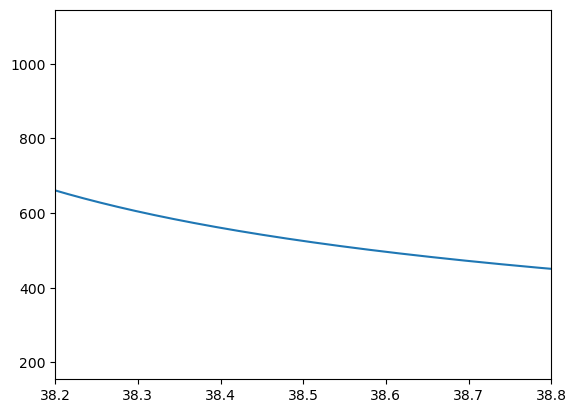

In [14]:
# Proving that the mean wavelength is to first order independent of small changes in SED shape



wave = np.linspace(300, 1100, 1000)


def dR(wave, zenith, pressure, temperature, H2O_pressure, step = 0.1):

    wave_upper = wave + step/2
    wave_lower = wave - step/2


    refraction_upper = galsim.dcr.get_refraction(
        wave_upper,
        zenith_angle=zenith * galsim.degrees,
        pressure=pressure,  # kPa
        temperature=temperature,  # K
        H2O_pressure=H2O_pressure,  # kPa
        ) * 180 * 3600 / np.pi #convert from radians to arcsec
    
    refraction_lower = galsim.dcr.get_refraction(
        wave_lower,
        zenith_angle=zenith * galsim.degrees,
        pressure=pressure,  # kPa
        temperature=temperature,  # K
        H2O_pressure=H2O_pressure,  # kPa
        ) * 180 * 3600 / np.pi #convert from radians to arcsec
    
    return (refraction_upper - refraction_lower)/step


def ddR(wave, zenith, pressure, temperature, H2O_pressure, step = 0.1):

    wave_upper = wave + step/2
    wave_lower = wave - step/2


    dr_upper = dR(wave_upper,zenith, pressure, temperature, H2O_pressure)

    dr_lower = dR(wave_lower,zenith, pressure, temperature, H2O_pressure)

    return (dr_upper - dr_lower)/step




flat_flux = np.ones(1000)

filtered_flux = {}

for band in 'ugrizy':
    filtered_flux[band] = apply_filter(wave, flat_flux, band = band)
    
mean, std = mean_and_std(wave, filtered_flux, multi = False)

for band in 'ugrizy':
    ddN = ddR(mean[band], 45, pressure, temperature, H2O_pressure)
    print(f'{band} (flat): var = {np.round(std[band]**2, 4)}, ddR = {np.round(ddN, 6)}') 
    print(np.round(std[band]**2 * ddN/2, 4))
    print('---')



wave = np.linspace(200, 1100, 5000)
R = refraction_upper = galsim.dcr.get_refraction(
        wave,
        zenith_angle= 45 * galsim.degrees,
        pressure=pressure,  # kPa
        temperature=temperature,  # K
        H2O_pressure=H2O_pressure,  # kPa
        ) * 180 * 3600 / np.pi #convert from radians to arcsec


mean_wave_est = interp1d(R, wave)
# ddN = ddR(wave, 45, pressure, temperature, H2O_pressure)
plt.plot(R, wave)

plt.xlim(38.2, 38.8)
